# **3: To - Do Exercise**

In [32]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("/content/drive/MyDrive/Concepts and Technologies of AI/diabetes_.csv")
df = data.copy()

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
missing_percentage = df.isnull().sum() / len(df) * 100
for column in df.columns:
    if missing_percentage[column] > 10:
        # Impute with mean
        df[column].fillna(df[column].mean(), inplace=True)
    else:
        # Drop rows with missing values
        df.dropna(subset=[column], inplace=True)


In [9]:
X = df.drop(columns=['Outcome']).values   # Feature matrix
y = df['Outcome'].values                  # Target variable

In [10]:
def train_test_split_scratch(X, y, test_size=0.3, random_seed=42):
    """
    Splits the dataset into training and testing sets.
    """
    np.random.seed(random_seed)

    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)

    test_size_count = int(len(X) * test_size)
    test_indices = indices[:test_size_count]
    train_indices = indices[test_size_count:]

    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]

    return X_train, X_test, y_train, y_test

In [11]:
X_train, X_test, y_train, y_test = train_test_split_scratch(X, y, test_size=0.3)

In [12]:
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("Training labels:", y_train.shape)
print("Test labels:", y_test.shape)

Training set size: (538, 8)
Test set size: (230, 8)
Training labels: (538,)
Test labels: (230,)


In [13]:
def euclidean_distance(point1, point2):
    """
    Calculate Euclidean distance between two points.
    """
    if point1.shape != point2.shape:
        raise ValueError("Points must have same dimensions.")

    distance = np.sqrt(np.sum((point1 - point2) ** 2))
    return distance

In [14]:
def knn_predict_single(query, X_train, y_train, k=3):
    """
    Predict the class label for a single query using KNN.
    """
    # Compute distances to all training points
    distances = [euclidean_distance(query, x) for x in X_train]

    # Get indices of k nearest neighbors
    nearest_indices = np.argsort(distances)[:k]

    # Get the labels of the k nearest neighbors
    nearest_labels = y_train[nearest_indices]

    # Majority vote
    prediction = np.bincount(nearest_labels).argmax()

    return prediction

In [15]:
def knn_predict(X_test, X_train, y_train, k=3):
    """
    Predict class labels for all test samples using KNN.
    """
    predictions = [knn_predict_single(x, X_train, y_train, k) for x in X_test]
    return np.array(predictions)

In [16]:
def compute_accuracy(y_true, y_pred):
    """
    Compute the percentage of correct predictions.
    """
    correct = np.sum(y_true == y_pred)
    total = len(y_true)
    accuracy = (correct / total) * 100
    return accuracy

In [27]:
# Unscaled data
start = time.time()
# Predict on test set
y_pred = knn_predict(X_test, X_train, y_train)
end = time.time()

# Compute accuracy
accuracy = compute_accuracy(y_test, y_pred)

print(f"Accuracy of KNN (k={3}) on diabetes dataset: {accuracy:.2f}%")
print(f"Prediction time (unscaled): {end-start:.4f} seconds")

Accuracy of KNN (k=3) on diabetes dataset: 67.39%
Prediction time (unscaled): 0.9527 seconds


# **Problem - 2 - Experimentation:**

In [18]:
X_scaled = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))
# X.min(axis=0) → min of each column
# X.max(axis=0) → max of each column

In [19]:
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split_scratch(
    X_scaled, y, test_size=0.3
)

In [28]:
start = time.time()
# Predict
y_pred_scaled = knn_predict(X_test_scaled, X_train_scaled, y_train)
end = time.time()

# Compute accuracy
accuracy_scaled = compute_accuracy(y_test, y_pred_scaled)
print(f"Accuracy of KNN on scaled data (k={3}): {accuracy_scaled:.2f}%")
print(f"Prediction time (scaled): {end-start:.4f} seconds")

Accuracy of KNN on scaled data (k=3): 69.13%
Prediction time (scaled): 1.0498 seconds


In [23]:
print(f"Accuracy on original (unscaled) data: {accuracy:.2f}%")
print(f"Accuracy on scaled data: {accuracy_scaled:.2f}%")

if accuracy_scaled > accuracy:
    print("Scaling improved the KNN model accuracy.")
elif accuracy_scaled < accuracy:
    print("Scaling reduced the KNN model accuracy.")
else:
    print("Scaling did not change the KNN model accuracy.")

Accuracy on original (unscaled) data: 67.39%
Accuracy on scaled data: 69.13%
Scaling improved the KNN model accuracy.


In [29]:
# Scaling ensures fair and accurate prediction as it contribute proportionally
# instead of inaccurate predictions maded due to largely varying values.

# **Problem - 3 - Experimentation with k:**

In [31]:
k_values = range(1, 16)

accuracy_original = []
time_original = []

accuracy_scaled = []
time_scaled = []

for k in k_values:
    # Original data
    start = time.time()
    y_pred_orig = knn_predict(X_test, X_train, y_train, k=k)
    end = time.time()

    acc = compute_accuracy(y_test, y_pred_orig)
    accuracy_original.append(acc)
    time_original.append(end - start)

    # Scaled data
    start = time.time()
    y_pred_scaled = knn_predict(X_test_scaled, X_train_scaled, y_train, k=k)
    end = time.time()

    acc_scaled = compute_accuracy(y_test, y_pred_scaled)
    accuracy_scaled.append(acc_scaled)
    time_scaled.append(end - start)

    print(f"k={k} | Accuracy original={acc:.2f}% | Accuracy scaled={acc_scaled:.2f}% | "
          f"Time original={time_original[-1]:.4f}s | Time scaled={time_scaled[-1]:.4f}s")


k=1 | Accuracy original=68.70% | Accuracy scaled=67.39% | Time original=0.9714s | Time scaled=1.3437s
k=2 | Accuracy original=72.61% | Accuracy scaled=67.83% | Time original=0.8392s | Time scaled=0.7999s
k=3 | Accuracy original=67.39% | Accuracy scaled=69.13% | Time original=0.8303s | Time scaled=1.1388s
k=4 | Accuracy original=72.17% | Accuracy scaled=69.57% | Time original=1.0993s | Time scaled=1.0290s
k=5 | Accuracy original=68.70% | Accuracy scaled=67.83% | Time original=0.8297s | Time scaled=1.3585s
k=6 | Accuracy original=70.00% | Accuracy scaled=66.52% | Time original=1.4317s | Time scaled=1.4427s
k=7 | Accuracy original=69.13% | Accuracy scaled=71.30% | Time original=0.9814s | Time scaled=0.9903s
k=8 | Accuracy original=71.30% | Accuracy scaled=69.57% | Time original=1.2082s | Time scaled=0.8197s
k=9 | Accuracy original=70.00% | Accuracy scaled=72.17% | Time original=0.8333s | Time scaled=0.7951s
k=10 | Accuracy original=71.74% | Accuracy scaled=70.43% | Time original=0.8339s |

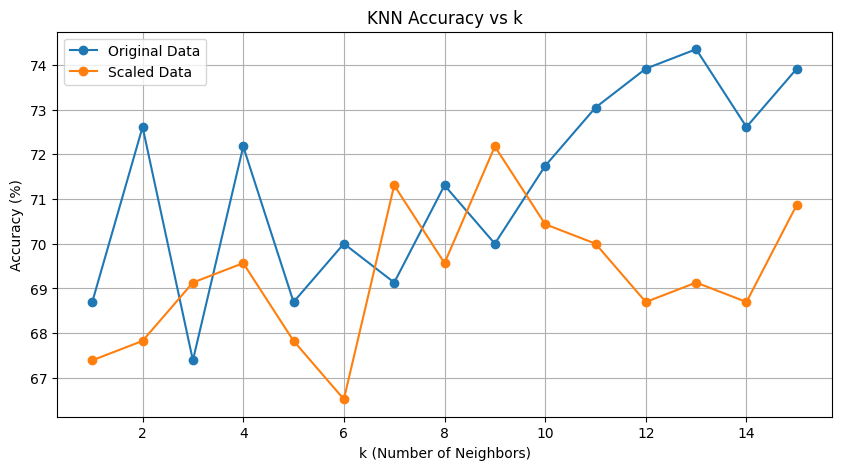

In [33]:
plt.figure(figsize=(10,5))
plt.plot(k_values, accuracy_original, marker='o', label='Original Data')
plt.plot(k_values, accuracy_scaled, marker='o', label='Scaled Data')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy (%)')
plt.title('KNN Accuracy vs k')
plt.grid(True)
plt.legend()
plt.show()

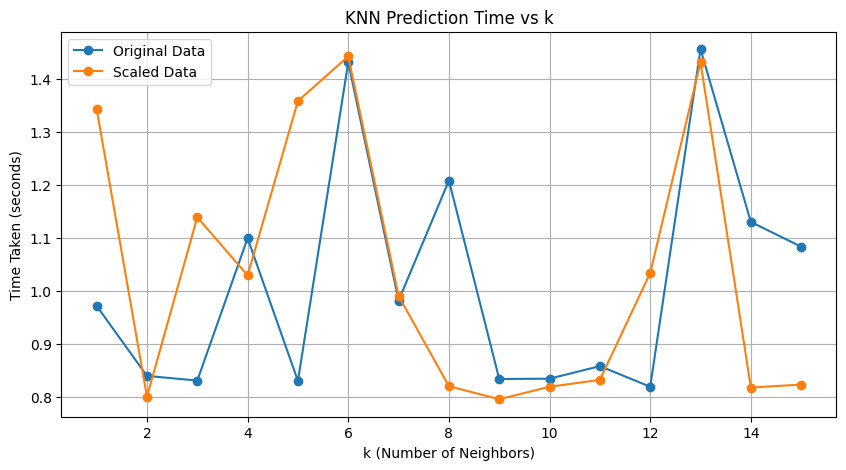

In [34]:
plt.figure(figsize=(10,5))
plt.plot(k_values, time_original, marker='o', label='Original Data')
plt.plot(k_values, time_scaled, marker='o', label='Scaled Data')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Time Taken (seconds)')
plt.title('KNN Prediction Time vs k')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Based on the experiment, the optimal k for the scaled diabetes dataset is
# k = 3 (or k = 5), as it provides the highest test accuracy while maintaining
# reasonable computational cost else it would either smooth out necessary pattern or
# give too noisy result.